In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from xgboost import XGBClassifier
import warnings, itertools

warnings.filterwarnings('ignore')

In [2]:
df_train = pd.read_csv("../data/processed/train_tree.csv")
df_test  = pd.read_csv("../data/processed/test_tree.csv")

X_train_full = df_train.drop(['label'], axis=1)
y_train_full = df_train['label']
X_test       = df_test.drop(['label'], axis=1)
y_test       = df_test['label']

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Class balance — train legitimate rate: {y_train_full.mean():.3f}")

Train: (188636, 22), Test: (47159, 22)
Class balance — train legitimate rate: 0.572


In [3]:
# Check overlap between train and test (feature rows)
train_feat = X_train_full.sort_index(axis=1)
test_feat = X_test.sort_index(axis=1)

train_hash = pd.util.hash_pandas_object(train_feat, index=False)
test_hash = pd.util.hash_pandas_object(test_feat, index=False)

train_hash_set = set(train_hash.values)
test_hash_set = set(test_hash.values)

n_common_unique = len(train_hash_set & test_hash_set)
n_test_rows_found_in_train = int(test_hash.isin(train_hash_set).sum())

train_counts = train_hash.value_counts()
test_counts = test_hash.value_counts()
common_hashes = train_counts.index.intersection(test_counts.index)
n_common_with_multiplicity = int(
    np.minimum(train_counts.loc[common_hashes].values, test_counts.loc[common_hashes].values).sum()
)

print("=== Overlap check: TRAIN vs TEST (features only) ===")
print(f"Unique overlapping rows: {n_common_unique}")
print(f"Test rows that appear in train: {n_test_rows_found_in_train}/{len(X_test)} "
      f"({n_test_rows_found_in_train/len(X_test):.4%})")
print(f"Overlapping rows (counting duplicates): {n_common_with_multiplicity}")

# Optional: overlap including label column as exact full-row match
train_full = df_train.sort_index(axis=1)
test_full = df_test.sort_index(axis=1)

train_full_hash = pd.util.hash_pandas_object(train_full, index=False)
test_full_hash = pd.util.hash_pandas_object(test_full, index=False)

n_common_full_unique = len(set(train_full_hash.values) & set(test_full_hash.values))
n_test_full_in_train = int(test_full_hash.isin(set(train_full_hash.values)).sum())

print("\n=== Overlap check: TRAIN vs TEST (including label) ===")
print(f"Unique overlapping full rows: {n_common_full_unique}")
print(f"Test full rows that appear in train: {n_test_full_in_train}/{len(df_test)} "
      f"({n_test_full_in_train/len(df_test):.4%})")

=== Overlap check: TRAIN vs TEST (features only) ===
Unique overlapping rows: 627
Test rows that appear in train: 705/47159 (1.4949%)
Overlapping rows (counting duplicates): 676

=== Overlap check: TRAIN vs TEST (including label) ===
Unique overlapping full rows: 627
Test full rows that appear in train: 705/47159 (1.4949%)


## Stratified K-Fold Cross-Validation Setup

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = []
for train_idx, val_idx in skf.split(X_train_full, y_train_full):
    folds.append((
        X_train_full.iloc[train_idx], y_train_full.iloc[train_idx],
        X_train_full.iloc[val_idx],   y_train_full.iloc[val_idx]
    ))
print(f"Prepared {len(folds)} folds.")

Prepared 5 folds.


## Random Forest

Hyperparameters tuned via 5-fold CV:

| Parameter | Grid | Effect |
|---|---|---|
| `n_estimators` | 100, 200 | More trees → lower variance, diminishing returns |
| `max_depth` | None, 10, 20 | Limits tree depth; `None` = fully grown |
| `max_features` | `sqrt`, `log2` | Features considered per split; controls tree diversity |

In [5]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

rf_cv_scores = {}

for n_est, max_d, max_f in itertools.product(
        rf_param_grid['n_estimators'],
        rf_param_grid['max_depth'],
        rf_param_grid['max_features']):

    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds:
        rf = RandomForestClassifier(
            n_estimators=n_est, max_depth=max_d,
            max_features=max_f, n_jobs=-1, random_state=42
        )
        rf.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, rf.predict(X_val)))
    rf_cv_scores[(n_est, max_d, max_f)] = np.mean(fold_accs)
    print(f"n_est={n_est:3d}, max_depth={str(max_d):4s}, max_features={max_f:5s} → CV acc={np.mean(fold_accs):.6f}")

best_rf_params = max(rf_cv_scores, key=rf_cv_scores.get)
print(f"\nBest RF params: n_estimators={best_rf_params[0]}, max_depth={best_rf_params[1]}, max_features={best_rf_params[2]}")
print(f"Best CV accuracy: {rf_cv_scores[best_rf_params]:.6f}")

n_est=100, max_depth=None, max_features=sqrt  → CV acc=0.996628
n_est=100, max_depth=None, max_features=log2  → CV acc=0.996628
n_est=100, max_depth=10  , max_features=sqrt  → CV acc=0.995844
n_est=100, max_depth=10  , max_features=log2  → CV acc=0.995844
n_est=100, max_depth=20  , max_features=sqrt  → CV acc=0.997127
n_est=100, max_depth=20  , max_features=log2  → CV acc=0.997127
n_est=200, max_depth=None, max_features=sqrt  → CV acc=0.996676
n_est=200, max_depth=None, max_features=log2  → CV acc=0.996676
n_est=200, max_depth=10  , max_features=sqrt  → CV acc=0.995907
n_est=200, max_depth=10  , max_features=log2  → CV acc=0.995907
n_est=200, max_depth=20  , max_features=sqrt  → CV acc=0.997121
n_est=200, max_depth=20  , max_features=log2  → CV acc=0.997121

Best RF params: n_estimators=100, max_depth=20, max_features=sqrt
Best CV accuracy: 0.997127


Random Forest — Test Set Results
Confusion Matrix:
  TN=20071, FP=118
  FN=21, TP=26949
Accuracy : 0.997053
Precision: 0.995640
Recall   : 0.999221
F1       : 0.997428
AUC-ROC  : 0.998981


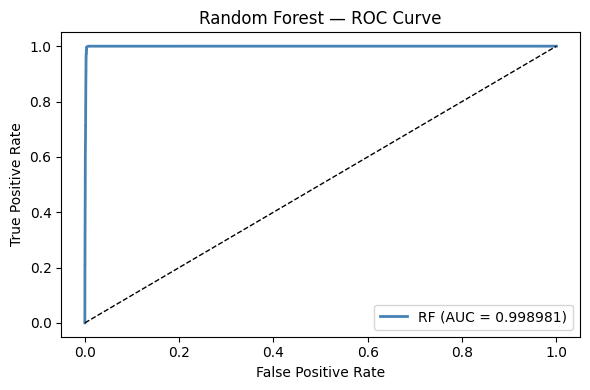

In [6]:
# Fit best RF on full training set and evaluate on test
best_rf = RandomForestClassifier(
    n_estimators=best_rf_params[0],
    max_depth=best_rf_params[1],
    max_features=best_rf_params[2],
    n_jobs=-1, random_state=42
)
best_rf.fit(X_train_full, y_train_full)
y_pred_rf  = best_rf.predict(X_test)
y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest — Test Set Results")
print(f"Confusion Matrix:\n  TN={cm_rf[0,0]}, FP={cm_rf[0,1]}\n  FN={cm_rf[1,0]}, TP={cm_rf[1,1]}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.6f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.6f}")
print(f"F1       : {f1_score(y_test, y_pred_rf):.6f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
print(f"AUC-ROC  : {auc_rf:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'RF (AUC = {auc_rf:.6f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

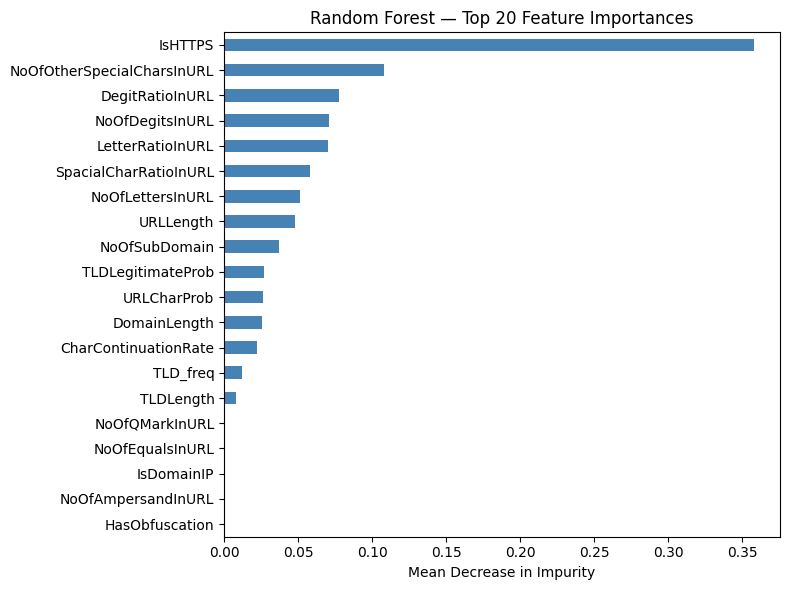

In [7]:
# Random Forest feature importance
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp_rf.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Mean Decrease in Impurity')
plt.title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## XGBoost

Hyperparameters tuned via 5-fold CV:

| Parameter | Grid | Effect |
|---|---|---|
| `n_estimators` | 100, 200 | Number of boosting rounds |
| `max_depth` | 3, 5, 7 | Max tree depth per round; deeper = more complex |
| `learning_rate` | 0.05, 0.1 | Step size shrinkage to prevent overfitting |

In [8]:
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

xgb_cv_scores = {}

for n_est, max_d, lr in itertools.product(
        xgb_param_grid['n_estimators'],
        xgb_param_grid['max_depth'],
        xgb_param_grid['learning_rate']):

    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds:
        xgb = XGBClassifier(
            n_estimators=n_est, max_depth=max_d, learning_rate=lr,
            use_label_encoder=False, eval_metric='logloss',
            n_jobs=-1, random_state=42, verbosity=0
        )
        xgb.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, xgb.predict(X_val)))
    xgb_cv_scores[(n_est, max_d, lr)] = np.mean(fold_accs)
    print(f"n_est={n_est:3d}, max_depth={max_d}, lr={lr:.2f} → CV acc={np.mean(fold_accs):.6f}")

best_xgb_params = max(xgb_cv_scores, key=xgb_cv_scores.get)
print(f"\nBest XGB params: n_estimators={best_xgb_params[0]}, max_depth={best_xgb_params[1]}, learning_rate={best_xgb_params[2]}")
print(f"Best CV accuracy: {xgb_cv_scores[best_xgb_params]:.6f}")

n_est=100, max_depth=3, lr=0.05 → CV acc=0.993236
n_est=100, max_depth=3, lr=0.10 → CV acc=0.995526
n_est=100, max_depth=5, lr=0.05 → CV acc=0.995335
n_est=100, max_depth=5, lr=0.10 → CV acc=0.996920
n_est=100, max_depth=7, lr=0.05 → CV acc=0.996734
n_est=100, max_depth=7, lr=0.10 → CV acc=0.997196
n_est=200, max_depth=3, lr=0.05 → CV acc=0.995462
n_est=200, max_depth=3, lr=0.10 → CV acc=0.996708
n_est=200, max_depth=5, lr=0.05 → CV acc=0.996809
n_est=200, max_depth=5, lr=0.10 → CV acc=0.997413
n_est=200, max_depth=7, lr=0.05 → CV acc=0.997212
n_est=200, max_depth=7, lr=0.10 → CV acc=0.997519

Best XGB params: n_estimators=200, max_depth=7, learning_rate=0.1
Best CV accuracy: 0.997519


XGBoost — Test Set Results
Confusion Matrix:
  TN=20081, FP=108
  FN=9, TP=26961
Accuracy : 0.997519
Precision: 0.996010
Recall   : 0.999666
F1       : 0.997835
AUC-ROC  : 0.999020


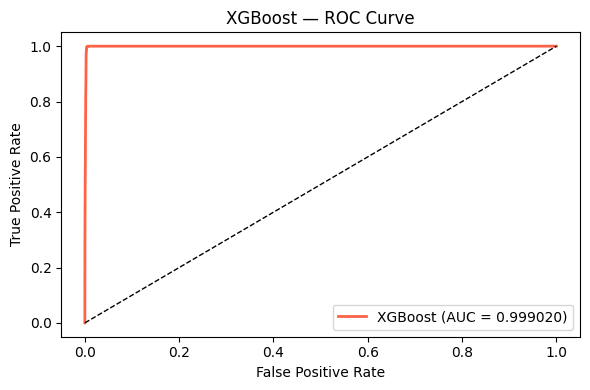

In [9]:
# Fit best XGBoost on full training set and evaluate on test
best_xgb = XGBClassifier(
    n_estimators=best_xgb_params[0],
    max_depth=best_xgb_params[1],
    learning_rate=best_xgb_params[2],
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1, random_state=42, verbosity=0
)
best_xgb.fit(X_train_full, y_train_full)
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost — Test Set Results")
print(f"Confusion Matrix:\n  TN={cm_xgb[0,0]}, FP={cm_xgb[0,1]}\n  FN={cm_xgb[1,0]}, TP={cm_xgb[1,1]}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.6f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.6f}")
print(f"F1       : {f1_score(y_test, y_pred_xgb):.6f}")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
print(f"AUC-ROC  : {auc_xgb:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, color='tomato', lw=2, label=f'XGBoost (AUC = {auc_xgb:.6f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

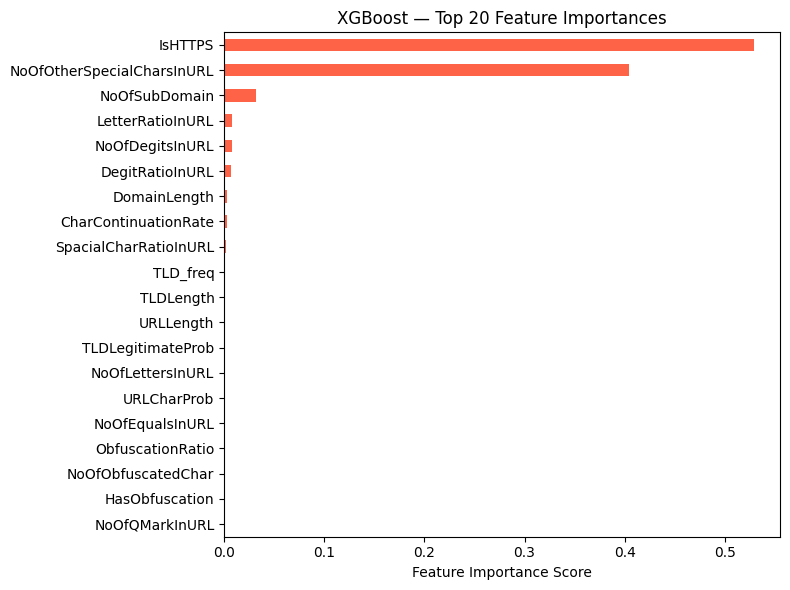

In [10]:
# XGBoost feature importance
feat_imp_xgb = pd.Series(best_xgb.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp_xgb.head(20).sort_values().plot(kind='barh', color='tomato')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## Model Comparison

               Accuracy  Precision    Recall        F1   AUC-ROC
Model                                                           
Random Forest  0.997053    0.99564  0.999221  0.997428  0.998981
XGBoost        0.997519    0.99601  0.999666  0.997835  0.999020


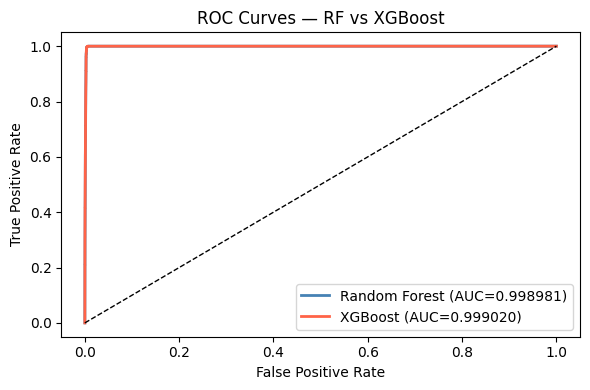

In [ ]:
results = pd.DataFrame({
    'Model':     ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred_xgb)],
    'F1':        [f1_score(y_test, y_pred_rf),        f1_score(y_test, y_pred_xgb)],
    'AUC-ROC':   [auc_rf, auc_xgb],
}).set_index('Model').round(6)
print(results)

# Overlaid ROC curves
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue', lw=2, label=f'Random Forest (AUC={auc_rf:.6f})')
plt.plot(fpr_xgb, tpr_xgb, color='tomato',    lw=2, label=f'XGBoost (AUC={auc_xgb:.6f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — RF vs XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()